In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from collections import Counter

path = kagglehub.dataset_download("vishardmehta/heart-risk-progression-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\vishardmehta\heart-risk-progression-dataset\versions\1


In [2]:
df = pd.read_csv(path+'\\cardiovascular_risk_dataset.csv')
df

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [3]:
df3 = df
df3 = df3.drop(['Patient_ID', 'risk_category'], axis = 1)
df3['smoking_status'] = df3['smoking_status'].map({'Current': 0, 'Former': 1, 'Never': 2})
df3['family_history_heart_disease'] = df3['family_history_heart_disease'].map({'No': 0, 'Yes': 1})
df3

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
0,62,25.0,142,93,247,72,2,11565,3,5.6,8.2,0,7,0.7,28.1
1,54,29.7,158,101,254,74,0,4036,8,0.5,6.7,0,5,4.5,63.0
2,46,36.2,170,113,276,80,0,3043,9,0.4,4.0,0,1,20.8,73.1
3,48,30.4,153,98,230,73,1,5604,5,0.6,8.0,0,4,8.5,39.5
4,46,25.3,139,87,206,69,0,7464,1,2.0,6.1,0,5,3.6,29.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,19,26.0,121,75,185,84,2,6724,3,2.9,7.2,0,7,0.0,0.0
5496,18,30.9,128,82,235,75,2,3661,4,0.0,5.5,0,1,9.6,16.8
5497,63,29.5,142,92,239,69,2,6643,5,4.1,6.9,0,6,2.4,31.8
5498,46,27.5,138,91,237,65,2,3279,3,2.4,5.8,1,5,2.3,29.4


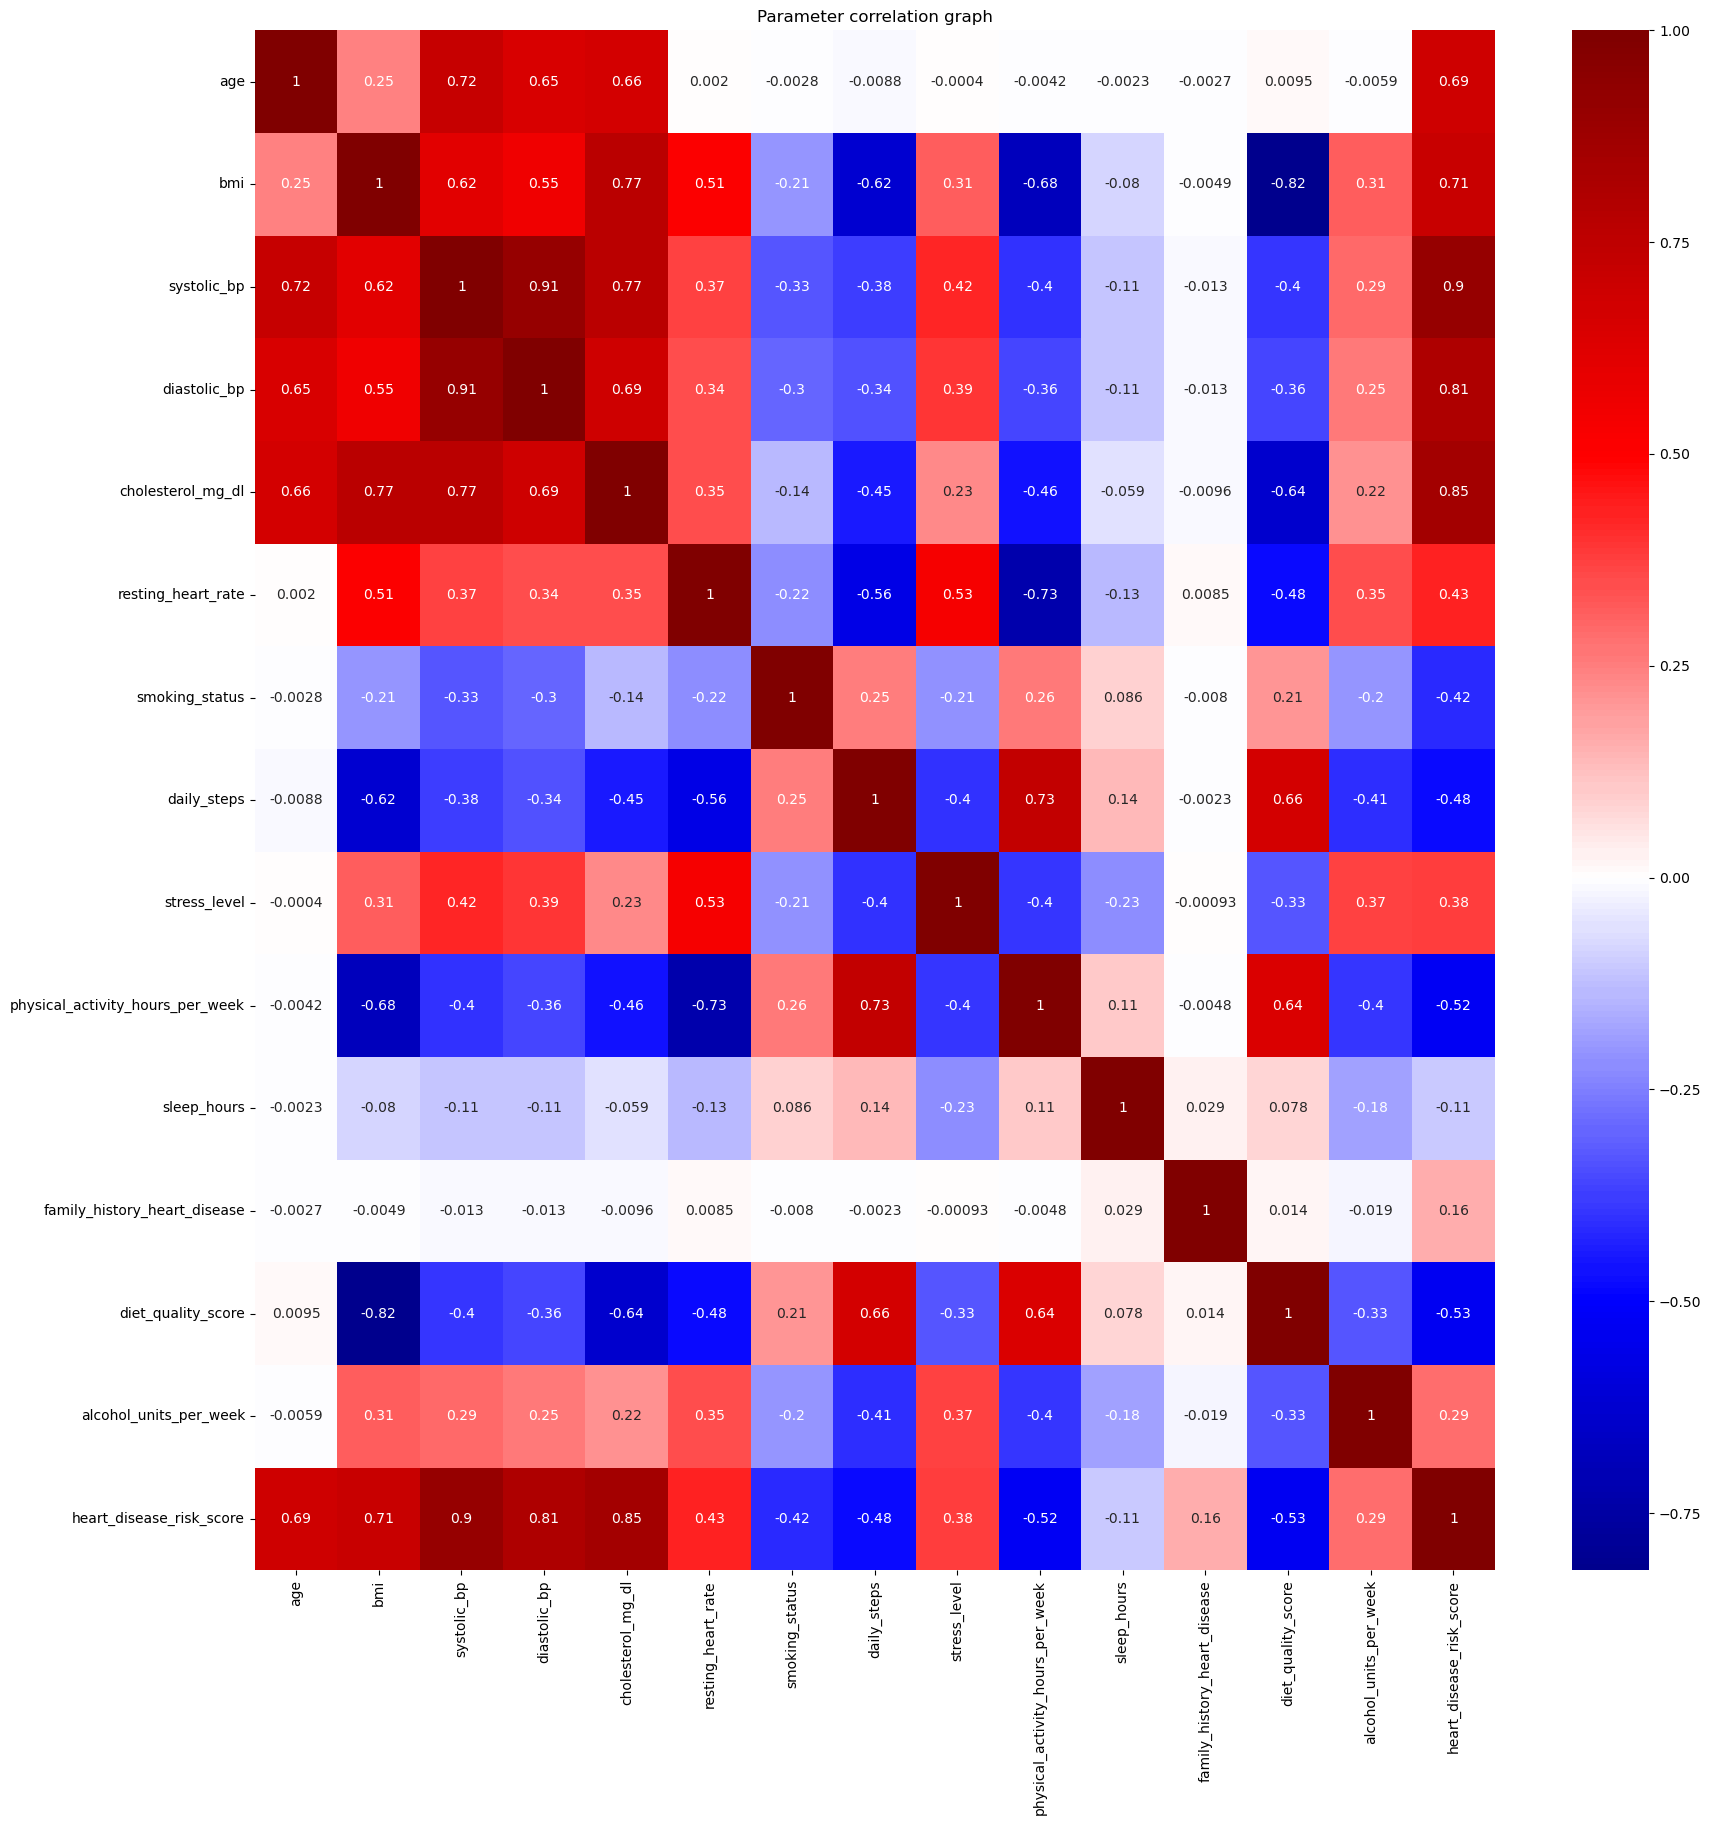

In [4]:
plt.figure(figsize=(20, 20))
seaborn.heatmap(df3.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [5]:
x = df3.drop(['heart_disease_risk_score'], axis = 1).to_numpy()
y = df3['heart_disease_risk_score'].to_numpy()

In [31]:
from sklearn.model_selection import train_test_split

x_train_f, x_test, y_train_f, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

gran = int(len(x_train)*0.1)

x_train = x_train_f[:gran]
y_train = y_train_f[:gran]

x_val = x_train_f[gran:]
y_val = y_train_f[gran:]

In [33]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.Dense(x_train.shape[1] * 5, activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(x_train.shape[1], activation ='relu', kernel_regularizer='l1'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1) 
])


model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                loss = 'mse',
                metrics = ['R2Score']
                )

early_stopping = EarlyStopping(
                    monitor='val_loss',
                    patience = 20,
                    min_delta = 0.01,
                    verbose = 0,
                    restore_best_weights = False
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 16,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle = False,
        validation_split = 0,
        validation_data = (x_val, y_val),
        validation_batch_size = 16
        )

train_loss, keras_train_r2 = model.evaluate(x_train, y_train)
test_loss, keras_test_r2 = model.evaluate(x_test, y_test)
print('\nдля нейронной сети R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)

D:\zmei\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - R2Score: 0.9115 - loss: 51.7361  
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - R2Score: 0.8983 - loss: 62.2029 

для нейронной сети R^2 метрика для обучающей \ тестовой выборки: 0.9115283489227295  \  0.8982822299003601


In [34]:
import torch
from torch.utils.data import Dataset, DataLoader

class my_Dataset(Dataset):
    
    def __init__(self, features, labels):

        self.features = torch.as_tensor(features, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.float32)

        self.mean = self.features.mean(dim = 0)
        self.std = self.features.std(dim = 0)
        
        self.normalized_features = (self.features - self.mean) / self.std
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.normalized_features[idx], self.labels[idx]
    
    def get_original(self, idx):
        return self.features[idx], self.labels[idx]

In [35]:
train_dataset = my_Dataset(x_train, y_train)   
val_dataset = my_Dataset(x_val, y_val)   
test_dataset = my_Dataset(x_test, y_test)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

In [36]:
import torch.nn as nn

class Regressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(x_train.shape[1], x_train.shape[1] * 5)
        self.act1 = nn.ReLU()
        self.drop = nn.Dropout(0.3)
        self.layer2 = nn.Linear(x_train.shape[1] * 5, x_train.shape[1])
        self.act2 = nn.ReLU()
        self.bath_norm = nn.BatchNorm1d(x_train.shape[1], eps = 0.001)
        self.last_layer = nn.Linear(x_train.shape[1], 1)
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.act1(out)
        out = self.drop(out)
        out = self.layer2(out)
        out = self.act2(out)
        out = self.bath_norm(out)
        out = self.last_layer(out)
        return out     


In [57]:
from sklearn.metrics import r2_score

def train_model(model, train_loader, val_loader, num_epochs = 2000, learning_rate = 1e-3):
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_r2': []
        }
    
    for epoch in range(num_epochs):

        train_loss = 0
        train_r2 = 0
        val_loss = 0

        all_labels = []
        all_predictions = []
        
        for batch_idx, (inputs, labels) in enumerate(train_loader):
           
            optimizer.zero_grad()
            
            outputs = model(inputs)

            if labels.dim() == 1:
                labels = labels.unsqueeze(1).float() 
            elif labels.dim() == 2 and labels.dtype != torch.float32:
                labels = labels.float()

            loss = criterion(outputs, labels)
            
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss += 0.01 * l1_norm
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

            all_labels.append(labels.detach().numpy())
            all_predictions.append(outputs.detach().numpy())

        all_labels_np = np.concatenate(all_labels, axis=0)
        all_predictions_np = np.concatenate(all_predictions, axis=0)
        train_r2 = r2_score(all_labels_np, all_predictions_np)
        avg_train_loss = train_loss / len(train_loader)

        for batch_idx, (inputs, labels) in enumerate(val_loader):

            outputs = model(inputs)

            if labels.dim() == 1:
                labels = labels.unsqueeze(1).float() 
            elif labels.dim() == 2 and labels.dtype != torch.float32:
                labels = labels.float()

            loss = criterion(outputs,labels)
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['train_r2'].append(train_r2)
        history['val_loss'].append(avg_val_loss)

        patiens = 20
        label_tmp = False
        
        if epoch > patiens:
            for i in range(patiens):
                if abs(history['val_loss'][epoch] - history['val_loss'][epoch - i]) < 0.01 and history['val_loss'][epoch] > history['val_loss'][epoch - i]:
                    label_tmp = True
                    break

        if epoch % 50 == 0:
            print(f"\nEpoch {epoch}/{num_epochs}:")
            print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Train r2: {train_r2:.4f}")

        if label_tmp == True:
            print('\nfinish')
            print(f"Epoch {epoch}/{num_epochs}:")
            print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Train r2: {train_r2:.4f}")
            break
    
    return model, history

In [58]:
model = Regressor(x.shape[1])

trained_model, history = train_model(
        model = model,
        train_loader = train_loader,
        val_loader = val_loader,
        num_epochs = 2000,
        learning_rate = 1e-3
        )


Epoch 0/2000:
Train Loss: 1852.8453, Val Loss: 1934.0649, Train r2: -2.2580

Epoch 50/2000:
Train Loss: 92.0376, Val Loss: 93.6814, Train r2: 0.8409

finish
Epoch 84/2000:
Train Loss: 52.9572, Val Loss: 61.5470, Train r2: 0.9131


In [59]:
def evaluate_model(model, test_loader):
    
    test_r2 = 0
    all_labels = []
    all_predictions = []
        
    for batch_idx, (inputs, labels) in enumerate(train_loader):
                      
        outputs = model(inputs)

        if labels.dim() == 1:
            labels = labels.unsqueeze(1).float() 
        elif labels.dim() == 2 and labels.dtype != torch.float32:
            labels = labels.float()

        all_labels.append(labels.detach().numpy())
        all_predictions.append(outputs.detach().numpy())

    all_labels_np = np.concatenate(all_labels, axis=0)
    all_predictions_np = np.concatenate(all_predictions, axis=0)
    test_r2 = r2_score(all_labels_np, all_predictions_np)
    
    #print(f"r2: {test_r2:.4f}%")
    return test_r2, all_predictions_np, all_labels_np

In [60]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # График потерь
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График валидационных потерь
    axes[0].plot(history['val_loss'], label='VAL Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Val Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График точности
    axes[1].plot(history['train_r2'], label='Train r2', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('r2')
    axes[1].set_title('Training r2')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
    plt.show()

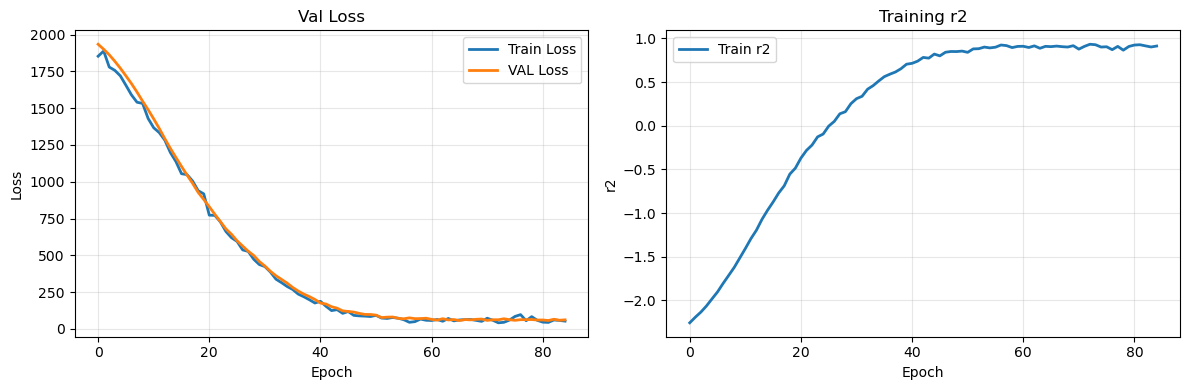

In [61]:
plot_training_history(history)

In [62]:
torch_test_r2, test_predictions, test_labels = evaluate_model(trained_model, test_loader)
torch_train_r2, train_predictions, train_labels = evaluate_model(trained_model, train_loader)

print(f'для нейронной сети из keras на одних и тех же настройках R^2 метрика\t для обучающей \ тестовой выборки: {keras_train_r2:.4f} \ {keras_test_r2:.4f}')
print(f'для нейронной сети из pytorch на одних и тех же настройках R^2 метрика\t для обучающей \ тестовой выборки: {torch_train_r2:.4f} \ {torch_test_r2:.4f}')

для нейронной сети из keras на одних и тех же настройках R^2 метрика	 для обучающей \ тестовой выборки: 0.9115 \ 0.8983
для нейронной сети из pytorch на одних и тех же настройках R^2 метрика	 для обучающей \ тестовой выборки: 0.8916 \ 0.9157


In [63]:
#не смотря на некоторое расхождение в R^2 метрике (~0.02) модели показывают схожие результаты